In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n


In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

learning_rate = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
num_episodes = 20000


In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    return int(np.argmax(Q[state]))


In [5]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = choose_action(state, epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)

        # Q-learning update:
        # Q(s,a) <- Q(s,a) + alpha * [r + gamma*max Q(s',a') - Q(s,a)]
        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        Q[state, action] += learning_rate * (target - Q[state, action])

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)

    # Gradually reduce exploration.
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

# Derive the state-value function and greedy policy from the learned Q-table.
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)


In [6]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [9]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

print("Name: VENKATANATHAN P R")
print("Reg No: 212223240173")

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.582 0.085 0.091 0.132]
 [0.    0.    0.065 0.136]
 [0.006 0.01  0.01  0.079]
 [0.001 0.004 0.007 0.038]
 [0.689 0.002 0.003 0.01 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.002 0.   ]
 [0.    0.    0.    0.   ]
 [0.027 0.014 0.002 0.81 ]
 [0.001 0.897 0.03  0.005]
 [0.935 0.001 0.001 0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.141 0.036 0.744 0.077]
 [0.748 0.989 0.264 0.191]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.582 0.136 0.079 0.038]
 [0.689 0.    0.002 0.   ]
 [0.81  0.897 0.935 0.   ]
 [0.    0.744 0.989 0.   ]]

Learned Policy:
[['L' 'U' 'U' 'U']
 ['L' 'L' 'R' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'R' 'D' 'L']]
Name: VENKATANATHAN P R
Reg No: 212223240173

Average reward over last 1000 episodes: 0.504


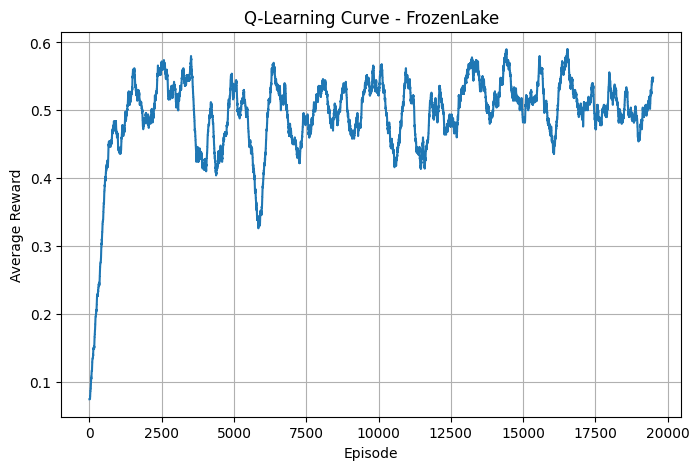

In [8]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()